In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F #moves data forward in function
import numpy as np

Using: cuda
Numpy version: 2.4.2


In [2]:
# Create Model Class that inherits nn.Module
class Model(nn.Module): #class = neural network, doing nn.Module means it is able to use all of these features
    #input layer with 4 features --> hidden layer 1 --> hidden layer 2 --> single output
    def __init__(self, in_features=3, h1=64, h2=32, out_features=1): #creates layers
        super().__init__() #sets up parent class initialisation of nn.Module
        self.fc1 = nn.Linear(in_features, h1) #creating hidden layer 1 here with in_features number of inputs and h1 number of outputs
        self.fc2 = nn.Linear(h1,h2) 
        self.out = nn.Linear(h2,out_features) #even for nonlinear datasets, nn.Linear is the choice here, just need to add activation later
    def forward(self,x): #function which moves data through network, x is the variable here which gets moved through
        x = F.relu(self.fc1(x)) #Activation ReLU function (Rectified Linear Unit)
        x = F.relu(self.fc2(x)) 
        x = self.out(x) #No activation function on final layer
        return x

In [3]:
torch.manual_seed(12)
model = Model() #create model

In [4]:
#Data pre processing - first, loading and compiling the data into a single df
import pandas as pd
import os

data_path = r'C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\data_out' #need to ensure datapath is correct to access data folder
all_nodes = [] #create empty list of data frames

for i in range(10000, 10020):
    file_path = os.path.join(data_path, f'nodes_{i}')
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1, names=[ 'dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4' ])
    all_nodes.append(df)
    
df = pd.concat(all_nodes, ignore_index=True) #combines into a single dataframe and removes indexing of each
print(df)

      dummy1      x      y     dx  dummy2  dummy3  dummy4
0         26 -0.500 -0.004  0.003  0.0072  0.0072       1
1         27 -0.497 -0.004  0.003  0.0072  0.0072      -1
2         28 -0.494 -0.004  0.003  0.0072  0.0072      -2
3         29 -0.491 -0.004  0.003  0.0072  0.0072      -3
4         30 -0.488 -0.004  0.003  0.0072  0.0072      -4
...      ...    ...    ...    ...     ...     ...     ...
7974    7950  0.500  0.010  0.003  0.0072  0.0072       2
7975    7951  0.497  0.010  0.003  0.0072  0.0072      -1
7976    7952  0.494  0.010  0.003  0.0072  0.0072      -2
7977    7953  0.491  0.010  0.003  0.0072  0.0072      -3
7978    7954  0.488  0.010  0.003  0.0072  0.0072      -4

[7979 rows x 7 columns]


In [5]:
import pandas as pd
import os
data_path = r'C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\data_out'
all_data = []

for i in range(10000, 10020):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows
    
    # Read fields  
    fields_df = pd.read_csv(os.path.join(data_path, f'fields_{i}_2'),
                           sep=r'\s+', skiprows=5, header=None, names=['density', 'u', 'v', 'vorticity', 'temperature', 
              'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4', 
              'ms5', 'ms6', 'ms7', 'ms8', 'ms9']) #/s+ seperation is for constant seperation which is more than one space
    
    # Combine nodes + fields
    combined = pd.concat([nodes_df, fields_df], axis=1) #horizontal merge of data, axis=1 specifies horizontal
    combined['processor'] = i
    all_data.append(combined) #adds this combined processor data to the list of dataframes all_data

# Final DataFrame with everything
df = pd.concat(all_data, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed
ms1_unburned = df['ms1'].max()
df['c'] = (1 - (df['ms1'] / ms1_unburned)).clip(0, 1)
print(f" Final shape: {df.shape}")
df

 Final shape: (7979, 25)


,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms2,ms3,ms4,ms5,ms6,ms7,ms8,ms9,processor,c
0,26,-0.500,-0.004,0.003,0.0072,0.0072,1,0.843706,2.049993,9.462150e-12,...,0.226501,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.745187,10000,1.122107e-09
1,27,-0.497,-0.004,0.003,0.0072,0.0072,-1,0.843706,2.049993,4.656218e-11,...,0.226501,7.841136e-31,-1.028150e-33,-7.394585e-31,-6.100516e-29,2.014742e-27,2.770231e-32,0.745187,10000,1.122127e-09
2,28,-0.494,-0.004,0.003,0.0072,0.0072,-2,0.843706,2.049993,5.883364e-11,...,0.226501,1.568227e-30,-2.056222e-33,-1.478917e-30,-1.220104e-28,4.029371e-27,3.146110e-32,0.745187,10000,1.122150e-09
3,29,-0.491,-0.004,0.003,0.0072,0.0072,-3,0.843706,2.049993,5.616350e-11,...,0.226501,2.352341e-30,-3.084249e-33,-2.218376e-30,-1.830157e-28,6.043934e-27,1.978784e-32,0.745187,10000,1.122177e-09
4,30,-0.488,-0.004,0.003,0.0072,0.0072,-4,0.843706,2.049993,4.347806e-11,...,0.226501,3.136455e-30,-4.112264e-33,-2.957835e-30,-2.440210e-28,8.058480e-27,1.729953e-33,0.745187,10000,1.122206e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7974,7950,0.500,0.010,0.003,0.0072,0.0072,2,0.123942,14.228926,8.971130e-04,...,0.009547,2.367017e-01,6.395209e-04,6.334371e-03,1.213254e-04,2.203018e-06,3.342610e-07,0.745151,10019,9.469312e-01
7975,7951,0.497,0.010,0.003,0.0072,0.0072,-1,0.123961,14.226784,9.011313e-04,...,0.009569,2.366621e-01,6.423568e-04,6.345731e-03,1.218893e-04,2.206033e-06,3.360365e-07,0.745151,10019,9.468195e-01
7976,7952,0.494,0.010,0.003,0.0072,0.0072,-2,0.123980,14.224625,9.051094e-04,...,0.009591,2.366225e-01,6.452033e-04,6.357091e-03,1.224551e-04,2.209065e-06,3.378227e-07,0.745151,10019,9.467077e-01
7977,7953,0.491,0.010,0.003,0.0072,0.0072,-3,0.123999,14.222444,9.090438e-04,...,0.009613,2.365827e-01,6.480655e-04,6.368471e-03,1.230237e-04,2.212120e-06,3.396229e-07,0.745151,10019,9.465957e-01


In [6]:
#Reducing DF to region of significant chemistry
df_filtered = df[df['c'].between(0.1, 0.9)]
df_filtered

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms2,ms3,ms4,ms5,ms6,ms7,ms8,ms9,processor,c
3121,3116,-0.035308,-0.001345,0.001,0.002700,0.002700,999,0.723857,2.397403,0.001060,...,0.224751,0.005771,0.000003,0.000033,0.000001,0.000342,0.000074,0.743555,10007,0.100386
3122,3123,-0.035260,0.007355,0.001,0.002700,0.002700,999,0.721872,2.404556,-0.001784,...,0.224706,0.005873,0.000003,0.000035,0.000001,0.000348,0.000075,0.743517,10007,0.101366
3123,3124,-0.035240,0.005412,0.001,0.002700,0.002700,999,0.720819,2.407623,-0.001226,...,0.224681,0.005922,0.000003,0.000036,0.000001,0.000350,0.000076,0.743499,10007,0.101774
3124,3125,-0.035233,-0.012174,0.001,0.002646,0.002646,999,0.720612,2.406169,0.001152,...,0.224676,0.005938,0.000003,0.000036,0.000001,0.000353,0.000076,0.743492,10007,0.101972
3125,3126,-0.035177,-0.009283,0.001,0.002541,0.002541,999,0.717855,2.415181,0.002437,...,0.224610,0.006070,0.000003,0.000038,0.000001,0.000358,0.000078,0.743447,10007,0.103087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5512,5515,0.063825,0.006524,0.001,0.002593,0.002593,999,0.137443,12.826221,0.000909,...,0.021661,0.217044,0.002872,0.010172,0.000600,0.000005,0.000003,0.744808,10013,0.899906
5513,5512,0.063830,-0.002440,0.001,0.002700,0.002700,999,0.137442,12.826295,0.000909,...,0.021661,0.217045,0.002872,0.010172,0.000600,0.000005,0.000003,0.744808,10013,0.899907
5514,5511,0.063876,0.008499,0.001,0.002593,0.002593,999,0.137435,12.826970,0.000909,...,0.021656,0.217053,0.002871,0.010172,0.000599,0.000005,0.000003,0.744808,10013,0.899922
5515,5516,0.063905,-0.000117,0.001,0.002700,0.002700,999,0.137430,12.827383,0.000909,...,0.021653,0.217057,0.002870,0.010171,0.000599,0.000005,0.000003,0.744809,10013,0.899931


In [7]:
#step 2 - specifying variables of interest
#For this basic model, 4 inputs, 1 output
model_variables = ['density','temperature','c','HRR']
model_data = df_filtered[model_variables]

print(model_data)

X=model_data[['density','temperature','c']].values
y=model_data['HRR'].values

       density  temperature         c           HRR
3121  0.723857   356.254976  0.100386  6.159117e+08
3122  0.721872   357.315389  0.101366  6.493856e+08
3123  0.720819   357.870300  0.101774  6.638371e+08
3124  0.720612   357.990286  0.101972  6.712471e+08
3125  0.717855   359.455320  0.103087  7.128608e+08
...        ...          ...       ...           ...
5512  0.137443  2077.202579  0.899906  8.429364e+08
5513  0.137442  2077.216294  0.899907  8.428626e+08
5514  0.137435  2077.341652  0.899922  8.421885e+08
5515  0.137430  2077.418224  0.899931  8.417770e+08
5516  0.137413  2077.716802  0.899966  8.401735e+08

[2396 rows x 4 columns]


In [8]:
from sklearn.model_selection import train_test_split
X_train_unscaled, X_unseen_unscaled, y_train_unscaled, y_unseen_unscaled = train_test_split(X,y,test_size=0.2,random_state=12) #must s
X_test_unscaled, X_val_unscaled, y_test_unscaled, y_val_unscaled = train_test_split(X_unseen_unscaled,y_unseen_unscaled,test_size=0.5,random_state=12)

#scale data
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_unscaled) #apply normalisation
X_val = scaler_X.transform(X_val_unscaled)   
X_test = scaler_X.transform(X_test_unscaled)        

y_train_log = np.log1p(y_train_unscaled)  
y_val_log = np.log1p(y_val_unscaled)  
y_test_log = np.log1p(y_test_unscaled)    
y_train = scaler_y.fit_transform(y_train_log.reshape(-1, 1))
y_val = scaler_y.transform(y_val_log.reshape(-1, 1))
y_test = scaler_y.transform(y_test_log.reshape(-1, 1))   

#convert numpy arrays into tensors for use in PyTorch
X_train = torch.FloatTensor(X_train) #for floats
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).view(-1,1) #reshape
y_val = torch.FloatTensor(y_val).view(-1,1) 
y_test = torch.FloatTensor(y_test).view(-1,1) 

In [9]:
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers

In [10]:
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers
best_val_loss = float('inf')
min_improvement = 0.02
patience = 30
patience_counter = 0

In [11]:
from codecarbon import EmissionsTracker #carbon emission tracker
import time

tracker = EmissionsTracker()
tracker.start()
start_training=time.time()

[codecarbon WARNING @ 17:58:48] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:58:50] [setup] RAM Tracking...
[codecarbon INFO @ 17:58:50] [setup] CPU Tracking...
[codecarbon WARNING @ 17:58:52] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 17:58:52] CPU Model on constant consumption mode: 12th Gen Intel(R) Core(TM) i7-12700H
[codecarbon WARNING @ 17:58:52] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 17:58:52] [setup] GPU Tracking...
[codecarbon INFO @ 17:58:52] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 17:58:52] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 17:58:52] >>> Tracker's metadata:
[code

In [12]:
epochs=10000
train_losses=[] #list which will be added to
val_losses=[]
for i in range(epochs):
    model.train() #training mode
    #go forward and predict
    y_pred=model.forward(X_train) #get predicted results
    #Measure loss
    train_loss = criterion(y_pred,y_train)
    train_losses.append(train_loss.detach().numpy()) #convert loss back from tensor to numpy

    #Back propagation (fine tuning of neuron parameters)
    optimiser.zero_grad() #resets gradient calculation (neccesary)
    train_loss.backward() #works out gradient for each weight (how much each weight contributed to error)
    optimiser.step() #gradient descent to update weight based on optimiser (optimiser determines how much to change weight by)

    #validation
    model.eval()  # evaluation mode
    with torch.no_grad():  # No gradient computation for validation
        y_val_pred = model.forward(X_val)
        val_loss = criterion(y_val_pred, y_val)
        val_losses.append(val_loss.detach().numpy())

    # Early stopping check
    if val_loss < best_val_loss * (1 - min_improvement):
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {i}, best val loss: {best_val_loss:.5f}")
        break
        
    #print every 50 epochs
    if i % 500 == 0: #% operator gives remainder 
        print(f'Epoch:{i}, Training loss: {train_loss}, Validation Loss: {val_loss}')

model.load_state_dict(torch.load('best_model.pt',weights_only=True))
print("Best model loaded")

Epoch:0, Training loss: 1.0120702981948853, Validation Loss: 1.028067708015442
Epoch:500, Training loss: 0.00037668863660655916, Validation Loss: 0.00033348382567055523
Epoch:1000, Training loss: 8.600897126598284e-05, Validation Loss: 5.548529952648096e-05
Early stopping at epoch 1253, best val loss: 0.00004
Best model loaded


In [13]:
training_time=time.time()-start_training
print(f"Training time: {training_time} secs")

training_emissions=tracker.stop()
print(f"Training Emissions: {training_emissions} kg CO2")

[codecarbon INFO @ 17:59:02] Energy consumed for RAM : 0.000036 kWh. RAM Power : 20.0 W


Training time: 5.505176544189453 secs


[codecarbon INFO @ 17:59:02] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 10.85713446825 W
[codecarbon INFO @ 17:59:02] Energy consumed for All CPU : 0.000020 kWh
[codecarbon INFO @ 17:59:02] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:59:02] Energy consumed for all GPUs : 0.000038 kWh. Total GPU Power : 19.60236720768169 W
[codecarbon INFO @ 17:59:02] 0.000094 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 2.2387832312480138e-05 kg CO2


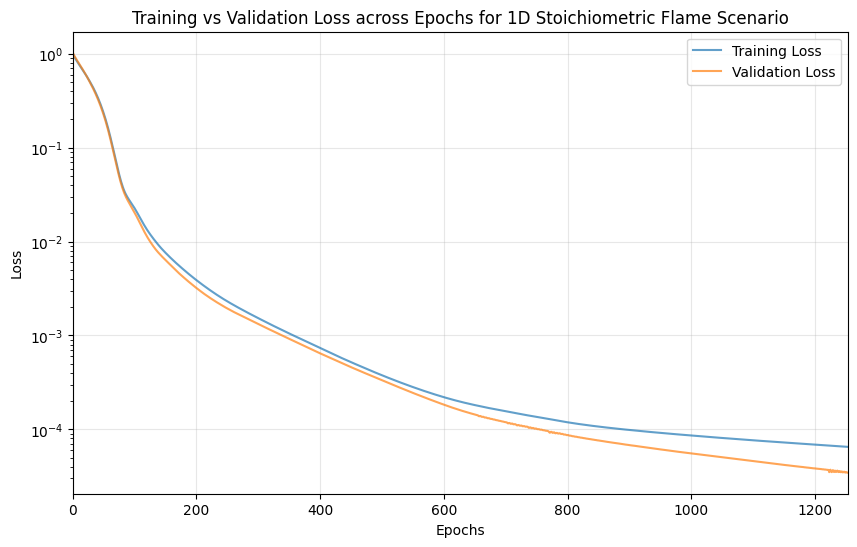

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0,i)
plt.title('Training vs Validation Loss across Epochs for 1D Stoichiometric Flame Scenario')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:

start_inference=time.time()

In [16]:
#Evaluate Model
with torch.no_grad():
    y_pred_scaled = model(X_test)
    
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled.numpy().reshape(-1, 1))
    y_test_log = scaler_y.inverse_transform(y_test.numpy().reshape(-1, 1))

    y_pred_actual = np.expm1(y_pred_log)  
    y_test_actual = np.expm1(y_test_log) 

In [17]:
inference_time=time.time()-start_inference
print(f"Inference time: {inference_time} secs, Inference time per sample: {inference_time/len(X_test)*1000:.4f}ms")

[codecarbon WARNING @ 17:59:04] Tracker already stopped !
[codecarbon INFO @ 17:59:04] Energy consumed for RAM : 0.000044 kWh. RAM Power : 20.0 W


Inference time: 0.01941704750061035 secs, Inference time per sample: 0.0809ms


[codecarbon INFO @ 17:59:04] Delta energy consumed for CPU with cpu_load : 0.000002 kWh, power : 5.228381484 W
[codecarbon INFO @ 17:59:04] Energy consumed for All CPU : 0.000022 kWh
[codecarbon INFO @ 17:59:04] Energy consumed for all GPUs : 0.000049 kWh. Total GPU Power : 18.96489967241798 W
[codecarbon INFO @ 17:59:04] 0.000115 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 2.7255795827144977e-05 kg CO2


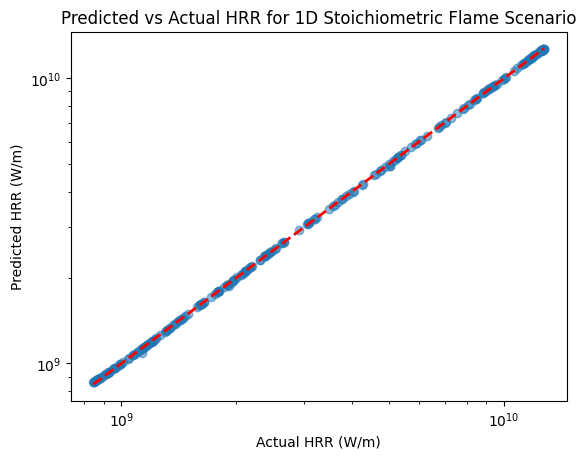

In [26]:
y_pred_np = y_pred_actual.flatten()
y_test_np = y_test_actual.flatten()

plt.scatter(y_test_np,y_pred_np,alpha=0.5)
plt.title('Predicted vs Actual HRR for 1D Stoichiometric Flame Scenario')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Actual HRR (W/m)')
plt.ylabel('Predicted HRR (W/m)')
plt.plot([y_test_np.min(), y_test_np.max()],   
         [y_test_np.min(), y_test_np.max()],   
         'r--', lw=2)
plt.show()

In [19]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

r2 = r2_score(y_test_np, y_pred_np)
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
nmse = mean_squared_error(y_test_np, y_pred_np)/np.var(y_test_np)

#new metric - normalised MSE


print(f"\nR² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")  
print(f"NMSE: {nmse:.5f}") 


R² Score: 1.0000
MAE:      13209849.00
RMSE:     20321787.92
MAPE: 0.40%
NMSE: 0.00002


In [20]:
#data checker
print(f"Predicted HRR range: {y_pred_np.min():.4f} to {y_pred_np.max():.4f}")
print(f"Actual HRR range:    {y_test_np.min():.4f} to {y_test_np.max():.4f}")

Predicted HRR range: 858914816.0000 to 12680587264.0000
Actual HRR range:    845032704.0000 to 12749437952.0000


In [1]:
#data checker
total_points = len(df)
filtered_points = len(df_filtered)
excluded_points = total_points - filtered_points

print(f"Total points before filtering: {total_points}")
print(f"Points retained (0.1 < c < 0.9): {filtered_points}")
print(f"Points excluded: {excluded_points} ({excluded_points/total_points*100:.1f}%)")

NameError: name 'df' is not defined